In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(
    "/content/Day3_customer_value_dataset.csv"
)


clean_df = df.copy()


clean_df["CouponCode"] = clean_df["CouponCode"].fillna(
    "No Coupon"
)


clean_df["Date"] = pd.to_datetime(
    clean_df["Date"]
)


clean_df["Month"] = clean_df["Date"].dt.month
clean_df["Year"] = clean_df["Date"].dt.year
clean_df["Day"] = clean_df["Date"].dt.day


clean_df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,HighValueOrder
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,4,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,23,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2,27,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,15,0
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5,8,1


In [3]:
median_price = clean_df["TotalPrice"].median()


clean_df["HighValueOrder"] = np.where(

    clean_df["TotalPrice"] > median_price,

    1,

    0

)


clean_df["HighValueOrder"].value_counts()

,count
HighValueOrder,
1,600
0,600


In [4]:
features = [

"Quantity",

"ItemsInCart",

"UnitPrice",

"Month",

"Product",

"PaymentMethod",

"ReferralSource",

"CouponCode"

]


X = clean_df[features]

y = clean_df["HighValueOrder"]

In [5]:
from sklearn.preprocessing import LabelEncoder


encoder = LabelEncoder()


for col in X.select_dtypes(include="object").columns:

    X[col] = encoder.fit_transform(
        X[col]
    )


X.head()

/tmp/ipykernel_3384/589237111.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encoder.fit_transform(
/tmp/ipykernel_3384/589237111.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encoder.fit_transform(
/tmp/ipykernel_3384/589237111.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/index

,Quantity,ItemsInCart,UnitPrice,Month,Product,PaymentMethod,ReferralSource,CouponCode
0,5,7,570.62,1,3,2,3,2
1,2,3,151.35,8,4,4,4,2
2,5,8,550.68,2,6,1,0,0
3,1,5,273.19,10,0,2,1,2
4,4,8,626.01,5,5,4,0,2


In [6]:
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)


rf_model = RandomForestClassifier(

    n_estimators=100,

    max_depth=5,

    min_samples_split=20,

    random_state=42

)


rf_model.fit(

    X_train,

    y_train

)


rf_prediction = rf_model.predict(

    X_test

)

In [7]:
print(

classification_report(

    y_test,

    rf_prediction

)

)

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       120
           1       0.97      0.98      0.98       120

    accuracy                           0.97       240
   macro avg       0.98      0.97      0.97       240
weighted avg       0.98      0.97      0.97       240



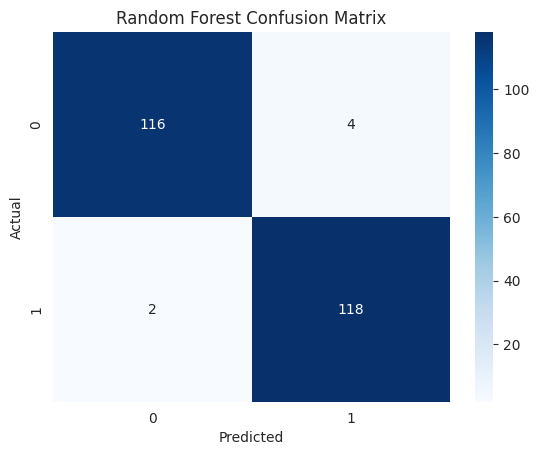

In [8]:
cm = confusion_matrix(

    y_test,

    rf_prediction

)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)


plt.title(
"Random Forest Confusion Matrix"
)


plt.xlabel(
"Predicted"
)


plt.ylabel(
"Actual"
)


plt.show()

In [9]:
importance_df = pd.DataFrame({

    "Feature": features,

    "Importance": rf_model.feature_importances_

})


importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)


importance_df

,Feature,Importance
2,UnitPrice,0.496544
0,Quantity,0.366056
1,ItemsInCart,0.084696
3,Month,0.018253
4,Product,0.010332
6,ReferralSource,0.009441
5,PaymentMethod,0.007730
7,CouponCode,0.006948


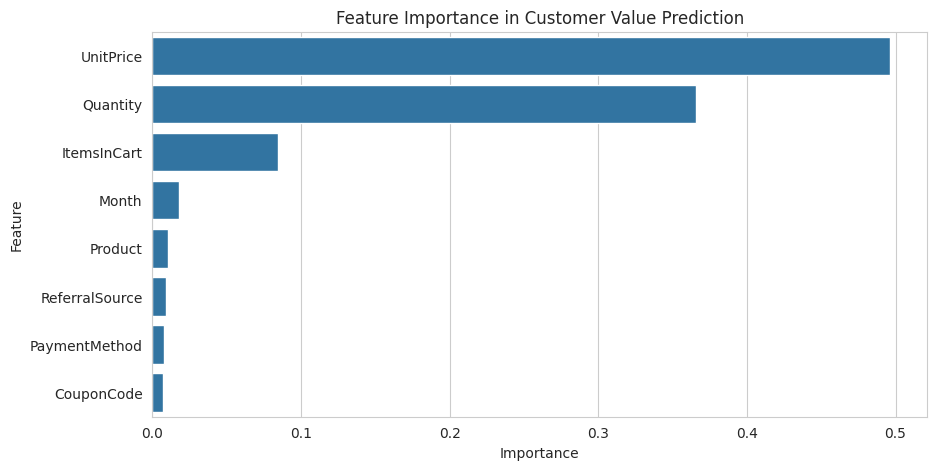

In [10]:
plt.figure(figsize=(10,5))


sns.barplot(

    data=importance_df,

    x="Importance",

    y="Feature"

)


plt.title(
"Feature Importance in Customer Value Prediction"
)


plt.show()

## Final Business Insights

1. Unit price and quantity were identified as the most influential factors driving high-value customer transactions.

2. Transaction behaviour features were more important than marketing-related features such as referral source and coupon usage.

3. Tree-based machine learning models successfully captured nonlinear relationships within customer purchasing patterns.

4. The developed pipeline demonstrates how machine learning can support customer segmentation and business decision-making.

5. Feature importance analysis improved model transparency by explaining the factors behind predictions.



## Conclusion

This project developed an end-to-end machine learning workflow for customer value prediction.

The pipeline included data cleaning, feature engineering, machine learning model development, evaluation, and model interpretation.

The final model provides insights into customer purchasing behaviour and demonstrates the application of machine learning in business analytics.